In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, StandardScaler

from google.colab import files
uploaded = files.upload()
filename = list(uploaded.keys())[0]

try:
    df = pd.read_csv(filename)
    print("✅ Dataset loaded successfully.")
    print(f"Initial shape: {df.shape}")
    print("Columns:", df.columns.tolist())
except Exception as e:
    print(f"❌ Failed to load dataset: {e}")
    exit()

for col in df.columns:
    if df[col].dtype in ['int64', 'float64']:
        if df[col].isnull().any():
            df[col].fillna(df[col].median(), inplace=True)
    elif df[col].dtype == 'object':
        if df[col].isnull().any():
            df[col].fillna(df[col].mode()[0], inplace=True)

categorical_cols = [col for col in df.columns if df[col].dtype == 'object' and col != 'Restaurant Name']
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

columns_to_drop = [
    'Restaurant ID', 'Restaurant Name', 'Address', 'Locality', 'Locality Verbose',
    'Currency', 'Switch to order menu', 'Rating color', 'Rating text'
]
df.drop(columns=[col for col in columns_to_drop if col in df.columns], inplace=True, errors='ignore')

df = df.apply(pd.to_numeric, errors='coerce')
df.dropna(inplace=True)
print(f"✅ Data cleaned. New shape: {df.shape}")


target_variable = 'Aggregate rating'
if target_variable not in df.columns:
    print(f"❌ Target variable '{target_variable}' not found.")
    exit()

X = df.drop(columns=[target_variable])
y = df[target_variable]


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X = pd.DataFrame(X_scaled, columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"✅ Split done. Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}


results = {}

import numpy as np

for name, model in models.items():
    print(f"\n🚀 Training {name}")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results[name] = {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}

    print(f"📊 MAE: {mae:.4f}")
    print(f"📊 MSE: {mse:.4f}")
    print(f"📊 RMSE: {rmse:.4f}")
    print(f"📊 R²: {r2:.4f}")

print("\n✅ Model Comparison Summary:")
for name, metrics in results.items():
    print(f"\nModel: {name}")
    for metric, value in metrics.items():
        print(f"  {metric}: {value:.4f}")


Saving Dataset (1).csv to Dataset (1) (3).csv
✅ Dataset loaded successfully.
Initial shape: (9551, 21)
Columns: ['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address', 'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu', 'Price range', 'Aggregate rating', 'Rating color', 'Rating text', 'Votes']
✅ Data cleaned. New shape: (9551, 12)
✅ Split done. Train: 7640, Test: 1911

🚀 Training Linear Regression
📊 MAE: 1.0521
📊 MSE: 1.5923
📊 RMSE: 1.2619
📊 R²: 0.3004

🚀 Training Decision Tree


/tmp/ipython-input-7-1028975681.py:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


📊 MAE: 0.2711
📊 MSE: 0.1773
📊 RMSE: 0.4211
📊 R²: 0.9221

🚀 Training Random Forest
📊 MAE: 0.1921
📊 MSE: 0.0879
📊 RMSE: 0.2964
📊 R²: 0.9614

✅ Model Comparison Summary:

Model: Linear Regression
  MAE: 1.0521
  MSE: 1.5923
  RMSE: 1.2619
  R2: 0.3004

Model: Decision Tree
  MAE: 0.2711
  MSE: 0.1773
  RMSE: 0.4211
  R2: 0.9221

Model: Random Forest
  MAE: 0.1921
  MSE: 0.0879
  RMSE: 0.2964
  R2: 0.9614


/tmp/ipython-input-8-3649617952.py:15: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


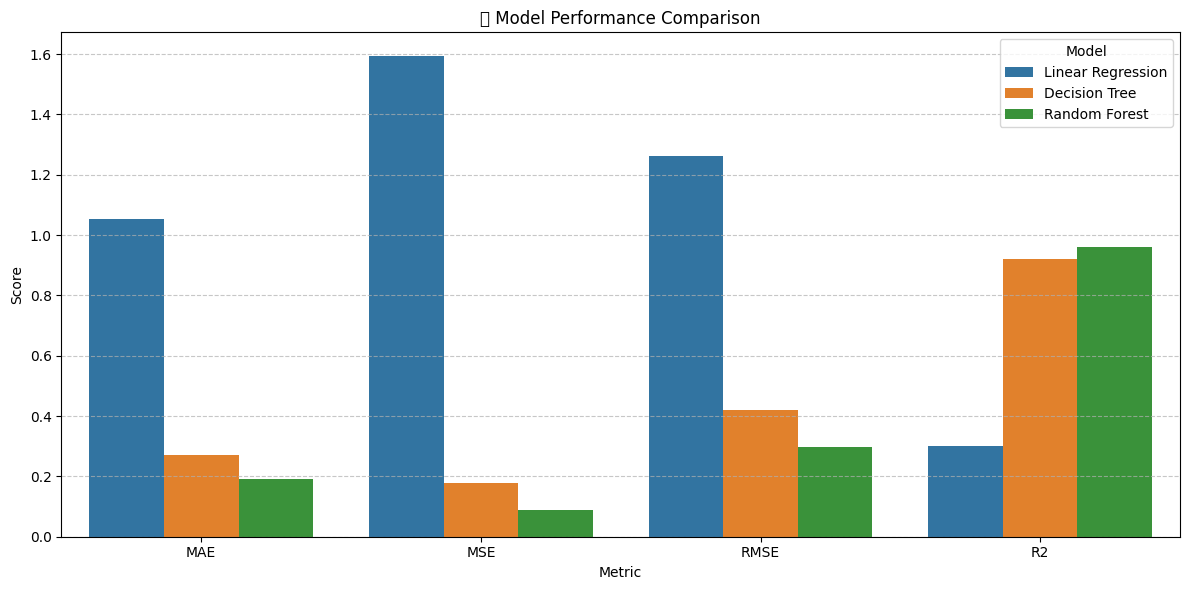

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns


metrics_df = pd.DataFrame(results).T.reset_index().rename(columns={"index": "Model"})

metrics_melted = metrics_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(12, 6))
sns.barplot(data=metrics_melted, x="Metric", y="Score", hue="Model")
plt.title("📊 Model Performance Comparison")
plt.ylabel("Score")
plt.legend(title="Model")
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


/tmp/ipython-input-9-3469695970.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance_df.head(15), x="Importance", y="Feature", palette="viridis")
/tmp/ipython-input-9-3469695970.py:15: UserWarning: Glyph 127794 (\N{EVERGREEN TREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127794 (\N{EVERGREEN TREE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


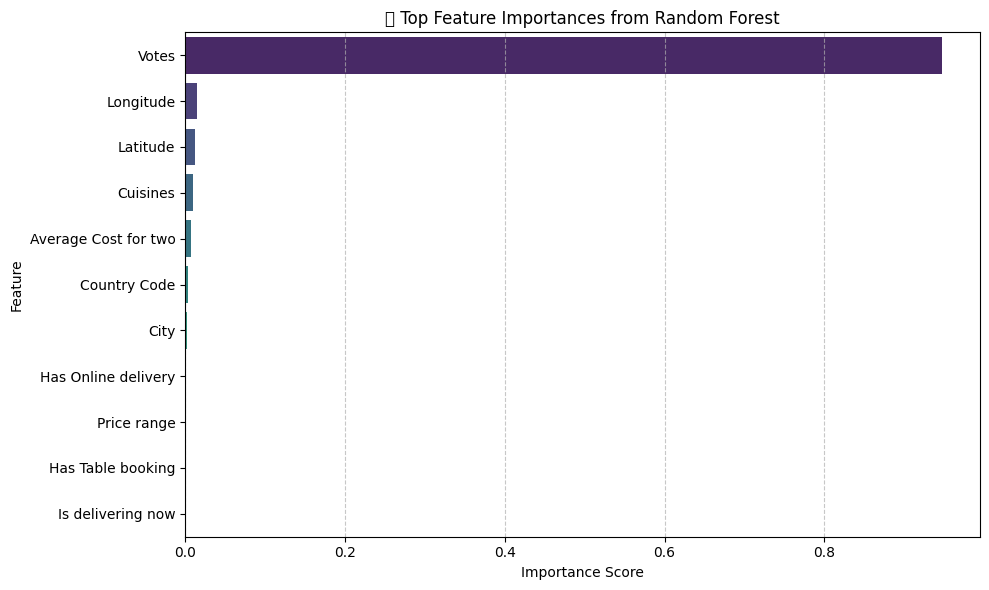

In [9]:

rf_model = models["Random Forest"]
if hasattr(rf_model, 'feature_importances_'):
    importances = rf_model.feature_importances_
    feature_importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=feature_importance_df.head(15), x="Importance", y="Feature", palette="viridis")
    plt.title("🌲 Top Feature Importances from Random Forest")
    plt.xlabel("Importance Score")
    plt.ylabel("Feature")
    plt.grid(True, axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("Feature importances not available for this model.")
